    Instructions:
    1. Run task_0a.py to generate the tensor database if not already generated.
    2. Press Run All (or restart kernel and run all cells).
    3. You will be prompted to provide input values.


    – Task 0b: Implement a program which, given (a) an (even or odd numbered) imageID or an image file, (b) a user
    selected feature space, and (c) positive integer k, identifies and visualizes the most similar k images, along with
    their scores, under the selected feature space.

In [169]:
IMG_ID = int(input("Provide an Image ID in the Caltech101 dataset in range [0, 8676]."))

FEATURE_SPACE = input("Provide a feature space [color, hog, avgpool, layer3, fc1000].")

K = int(input("Enter K, the number of similar images K to find for the selected feature space."))

In [170]:
# Initialize dataset, downloads into <git_root>/../caltech101 if not present. Untracked by git.

import os
from torchvision.datasets import Caltech101

dataset = Caltech101(root=os.path.abspath(""), download=True)

Files already downloaded and verified


Input image:
Image ID:  2500


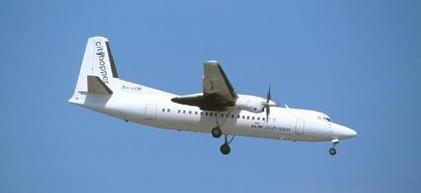

Category: airplanes


In [171]:
# Find the k most similar images for a given Image ID for the given feature space.

image, category = dataset[IMG_ID][0], dataset.categories[dataset[IMG_ID][1]]

if image.mode != 'RGB':
    print("WARNING: The provided image does not have RGB channels, the image will be converted to RGB.")
    image = image.convert('RGB')

print("Input image:\nImage ID: ", IMG_ID)
display(image)
print("Category:", category)

In [172]:
if FEATURE_SPACE == 'color':
    # Resize to 300x100 and partition to grid.

    image300x100 = image.resize((300, 100))

    from utils.utilities import partition_to_grid

    grid = partition_to_grid(image300x100, num_rows=10, num_cols=10, hor_pixels=30, ver_pixels=10)

    from feature_extractors.color_moments import get_color_vector

    vector = get_color_vector(grid)

    # Manhattan distance (City-block distance): This distance can be imagined as the length needed 
    # to move between two points in a grid where you can only move up, down, left or right. This 
    # measure is sensitive to differences along each dimension of the feature vectors, capturing 
    # the total absolute difference between corresponding moments, which makes it great for 
    # assessing differences in color distribution in terms of absolute deviations. Since it 
    # does not square the differences like Euclidean distance, it is less susceptible outliers 
    # when many dimensions differ.

    # We use Earth Mover's Distance (Wasserstein distance) as color moments can be thought
    # of as probability distributions over color space. EMD is capable of comparing distributions
    # with different shapes and scales, color moments consider the spatial arrangement of colors, 
    # not just the frequency of colors. EMD takes this spatial information into account by 
    # considering how color probability mass is transported from one distribution to another. 

    from scipy.spatial.distance import cityblock
    distance_fn = cityblock

elif FEATURE_SPACE == 'hog':
    # Convert to grayscale and partition to grid.

    from torchvision.transforms import Grayscale

    gs_image = Grayscale()(image300x100)

    gs_grid = partition_to_grid(gs_image, num_rows=10, num_cols=10, hor_pixels=30, ver_pixels=10)
    
    from feature_extractors.HOG import get_hog_vector

    vector = get_hog_vector(gs_grid)

    # Correlation similarity: This measures the linear relationship between HOG feature vectors,
    # and performs well with features that have a strong linear correlation or dependency in 
    # their gradient orientation distributions, taking into account directionality.

    from scipy.spatial.distance import correlation
    distance_fn = correlation

else:
    # Resize original image to 224x224 and convert to float tensor.

    from torchvision.transforms import transforms

    image224x224 = image.resize((224, 224))

    img_tensor = transforms.Compose([transforms.ToTensor()])(image224x224)

    from feature_extractors.resnet_50 import get_resnet50_feature_vectors

    avgpool_vector, layer3_vector, fc1000_vector = get_resnet50_feature_vectors(img_tensor)

    if FEATURE_SPACE == 'avgpool':
        vector = avgpool_vector
    elif FEATURE_SPACE == 'layer3':
        vector = layer3_vector
    else:
        vector = fc1000_vector

    # Cosine similarity: We use Cosine since the output of the ResNet layer is 
    # normalized, reducing the importance of magnitude. It is good at discerning 
    # semantic or structural similarity rather than their absolute feature values. 
    # It also works well with sparse feature spaces such as those found in CNNs.

    from scipy.spatial.distance import cosine
    distance_fn = cosine

Similar images by Color Moments using distance: Manhattan (cityblock)
1. 	Image ID:  2500 		Distance:  0.0


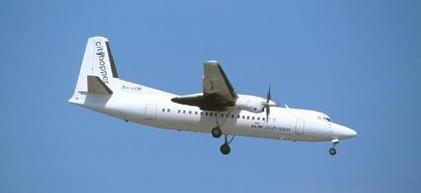

2. 	Image ID:  2301 		Distance:  10972.34


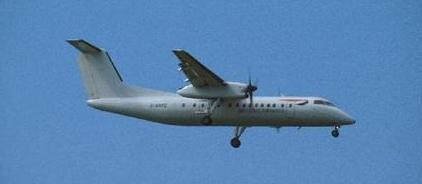

3. 	Image ID:  2519 		Distance:  11094.308


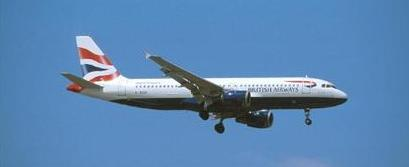

4. 	Image ID:  2524 		Distance:  11336.744


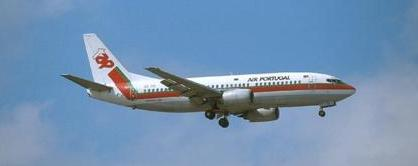

5. 	Image ID:  2308 		Distance:  12073.262


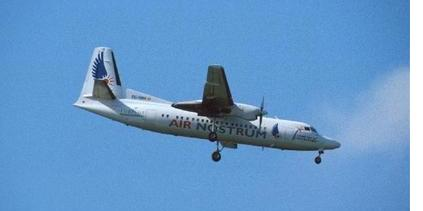

6. 	Image ID:  2196 		Distance:  12535.328


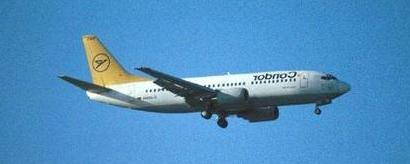

7. 	Image ID:  2245 		Distance:  12603.198


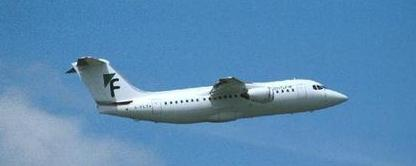

8. 	Image ID:  2410 		Distance:  13100.132


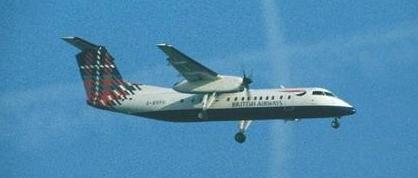

9. 	Image ID:  5007 		Distance:  13128.953


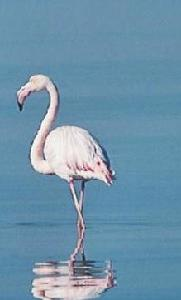

10. 	Image ID:  2670 		Distance:  13422.051


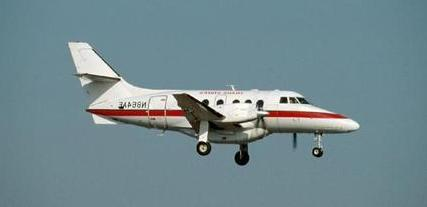

In [173]:
# Load feature space tensor database into memory.

from utils.utilities import tensor_loader

tensor_dict = tensor_loader(f'even_{FEATURE_SPACE}_tensors.pt', os.path.abspath(""))

from utils.utilities import top_k_ranker


top_k = top_k_ranker(K, vector, tensor_dict, distance_fn)


for i in range(len(top_k)):

    distance = top_k[i][0]
    id = top_k[i][1]
    category = top_k[i][2]

    print(str(i + 1) + ".", "\tImage ID: ", id, "\t\tCategory: ", category, "\t\tDistance: ", distance)
    display(dataset[id][0])